# 3. Sobel and Canny Edge Detection

## Table of Contents
1. [Libraries](#libraries)
2. [Sobel Edge Detection](#sobel)
3. [Canny Edge Detection](#canny)

## Importing Libraries <a class="anchor" id="libraries" ></a>

In [1]:
import cv2
import skimage
import numpy as np
from scipy import ndimage
from skimage import exposure
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scipy.ndimage import convolve
from scipy.ndimage import gaussian_filter as gauss
from scipy.ndimage import median_filter as med

## Sobel Edge Detection <a class="anchor" id="sobel" ></a>

As a first step in extracting features, you will apply the Sobel edge detection algorithm. This finds regions of the image with large gradient values in multiple directions. Regions with high omnidirectional gradient are likely to be edges or transitions in the pixel values. 

The code in the cell below applies the Sobel algorithm to the median filtered image, using these steps:

1. Convert the color image to grayscale for the gradient calculation since it is two dimensional.
2. Compute the gradient in the x and y (horizontal and vertical) directions. 
3. Compute the magnitude of the gradient.
4. Normalize the gradient values. 

In [2]:
def edge_sobel(image):
    from scipy import ndimage
    import skimage.color as sc
    import numpy as np
    image = sc.rgb2gray(image) # Convert color image to gray scale
    dx = ndimage.sobel(image, 1)  # horizontal derivative
    dy = ndimage.sobel(image, 0)  # vertical derivative
    mag = np.hypot(dx, dy)  # magnitude
    mag *= 255.0 / np.amax(mag)  # normalize (Q&D)
    mag = mag.astype(np.uint8)
    return mag

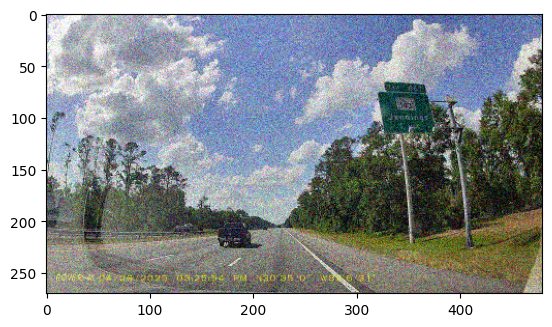

In [3]:
original_image = np.load('data/img.npy')

img = skimage.util.random_noise(original_image)
plt.imshow(img)

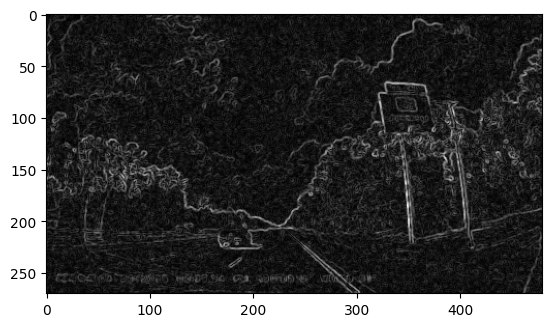

In [4]:
img_med = med(img, size=2)
img_edge = edge_sobel(img_med)
plt.imshow(img_edge, cmap="gray")

Now let's try with the more blurred gaussian filtered image.

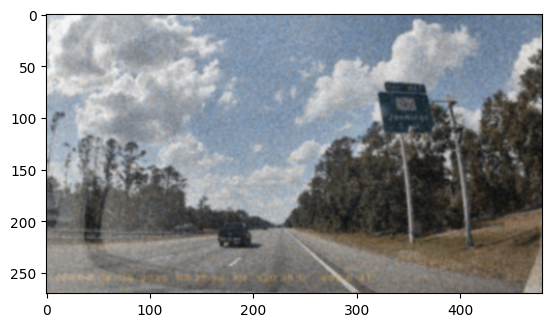

In [5]:
img_gauss = gauss(img, sigma=1)   
plt.imshow(img_gauss)

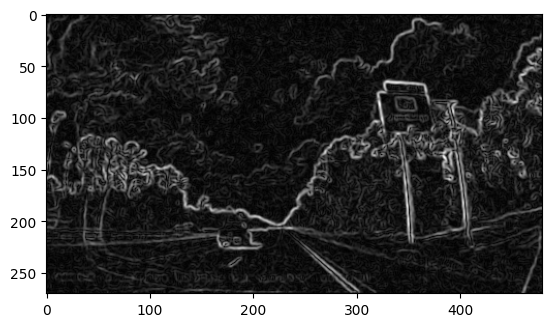

In [6]:
img_edge = edge_sobel(img_gauss)
plt.imshow(img_edge, cmap="gray")

## Canny Edge Detection <a class="anchor" id="canny" ></a>

Steps:
1. Noise Reduction
2. Gradient Calculation
3. Non-maximum Supression
4. Double Threshold
5. Edge Tracking by Hysteresis

**Pre-requisite:** Convert the image to grayscale before algorithm.

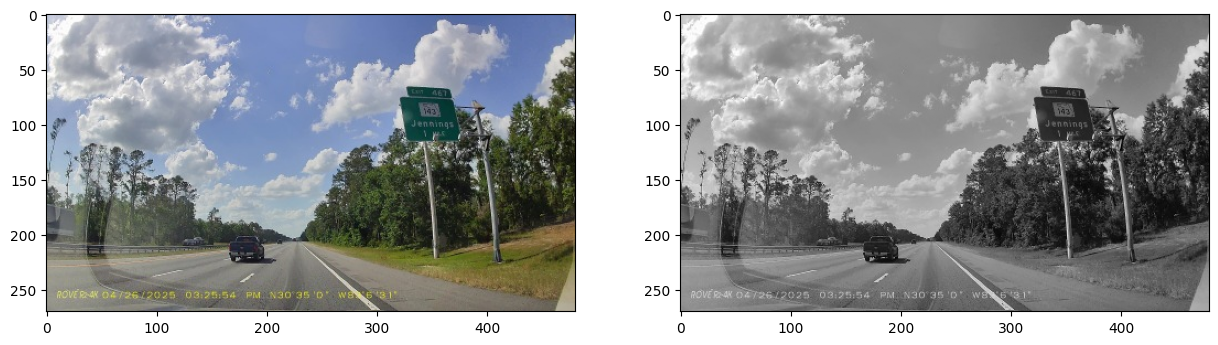

In [7]:
img = cv2.imread('data/image.jpg')

img_color = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.imshow(img_color)
plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap="gray")

### 1. Noise Reduction
Edge detection are highly sensitive to image noise due to the derivatives behind the algorithm.

We can apply a Gaussian Kernel, the size of the kernel depends on the expected blurring effect. The smaller the less blurring effect.

Equation for Gaussian Kernel of size $(2k+1) \times (2k+1)$

$$
H_{i, j} = \frac{1}{2\pi\sigma^2}exp(-\frac{(i-(k+1))^2 + (j-(k+1))^2}{2\sigma^2}); 1\leq i, j \leq (2k+1)
$$

In [8]:
def gaussian_kernel(size, sigma=1):
    size = int(size) // 2
    x, y = np.mgrid[-size:size+1, -size:size+1]
    normal = 1 / (2.0 * np.pi * sigma**2)
    g =  np.exp(-((x**2 + y**2) / (2.0*sigma**2))) * normal
    return g

### 1.1 Sigma Parameter $\sigma$

In [9]:
# Change this parameter
sigma = 10 # 1, 3, 5, 10, 20, ...

### 1.2 Kernel Size Parameter

In [10]:
kernel_size = 3

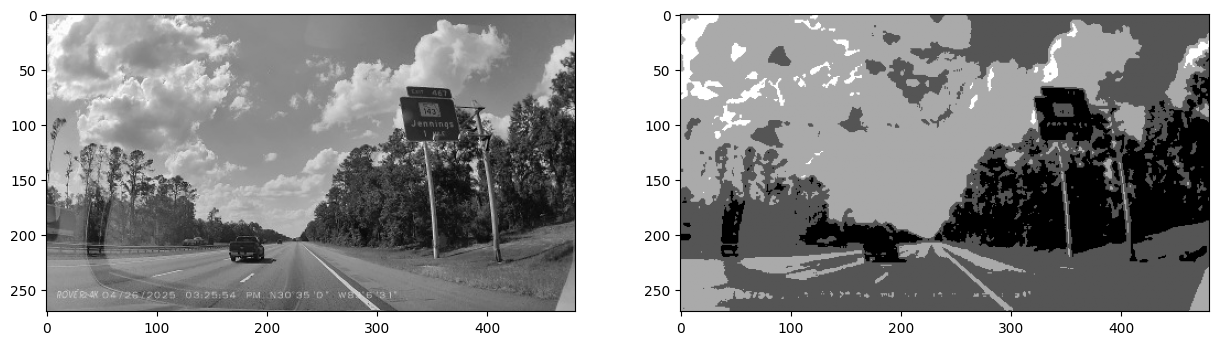

In [11]:
img_gaussian = convolve(img_gray, gaussian_kernel(kernel_size, sigma))

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(img_gaussian, cmap="gray")

### 2. Gradient Calculation

Edges correspond to a change of pixels intensity. 

To detect it, the easiest way is to apply filters that highlight this intensity change in both directions: 
- horizontal $(x)$ 
- and vertical $(y)$

It can be implemented by convoling $I$ with *Sobel kernels* $Kx$ and $Ky$

$$
K_x = \begin{bmatrix}
-1 & 0 & 1\\
-2 & 0 & 2\\
-1 & 0 & 1
\end{bmatrix}, K_y = \begin{bmatrix}
1 & 2& 1\\
0 & 0 & 0\\
-1 & -2 & -1
\end{bmatrix}
$$

Then, the magnitude $G$ and the slope $\theta$ of the gradient are calculated as follow:

$$
|G| = \sqrt{I_x^2 + I_y^2},
\theta(x, y) = arctan(\frac{I_y}{I_x})
$$

In [12]:
def sobel_filters(img):
    Kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], np.float32)
    Ky = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], np.float32)
    
    Ix = ndimage.convolve(img, Kx)
    Iy = ndimage.convolve(img, Ky)
    
    G = np.hypot(Ix, Iy)
    G = G / G.max() * 255
    theta = np.arctan2(Iy, Ix)
    
    return (G, theta)

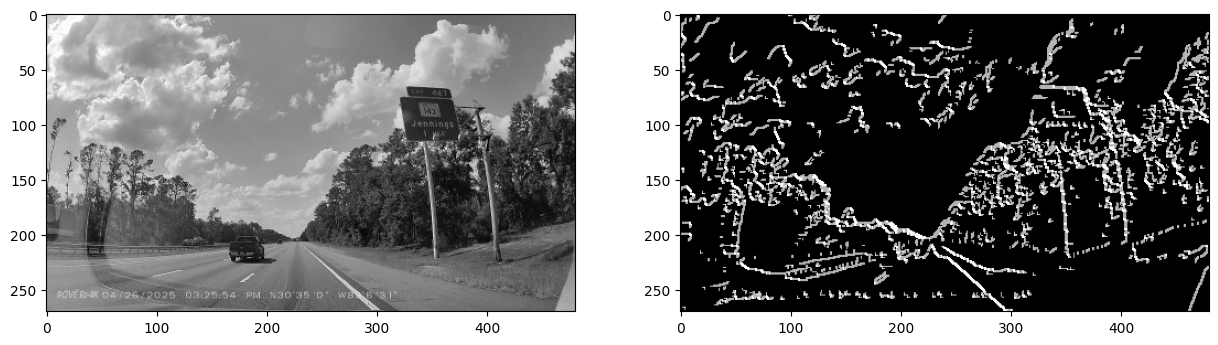

In [13]:
G, theta = sobel_filters(img_gaussian)

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(G, cmap="gray")

### 3. Non-Maximum supression

1. Create a matrix initialized to 0 of the same size of the original gradient intensity matrix
2. Identify the edge direction based on the angle value from the angle matrix
3. Check if the pixel in the same direction has a higher intensity than the pixel that is currently processed
4. Return the image processed with the non-max suppression algorithm.

In [14]:
def non_max_suppression(img, D):
    M, N = img.shape
    Z = np.zeros((M,N), dtype=np.int32)
    angle = D * 180. / np.pi
    angle[angle < 0] += 180

    
    for i in range(1,M-1):
        for j in range(1,N-1):
            try:
                q = 255
                r = 255
                
               #angle 0
                if (0 <= angle[i,j] < 22.5) or (157.5 <= angle[i,j] <= 180):
                    q = img[i, j+1]
                    r = img[i, j-1]
                #angle 45
                elif (22.5 <= angle[i,j] < 67.5):
                    q = img[i+1, j-1]
                    r = img[i-1, j+1]
                #angle 90
                elif (67.5 <= angle[i,j] < 112.5):
                    q = img[i+1, j]
                    r = img[i-1, j]
                #angle 135
                elif (112.5 <= angle[i,j] < 157.5):
                    q = img[i-1, j-1]
                    r = img[i+1, j+1]

                if (img[i,j] >= q) and (img[i,j] >= r):
                    Z[i,j] = img[i,j]
                else:
                    Z[i,j] = 0

            except IndexError as e:
                pass
    
    return Z

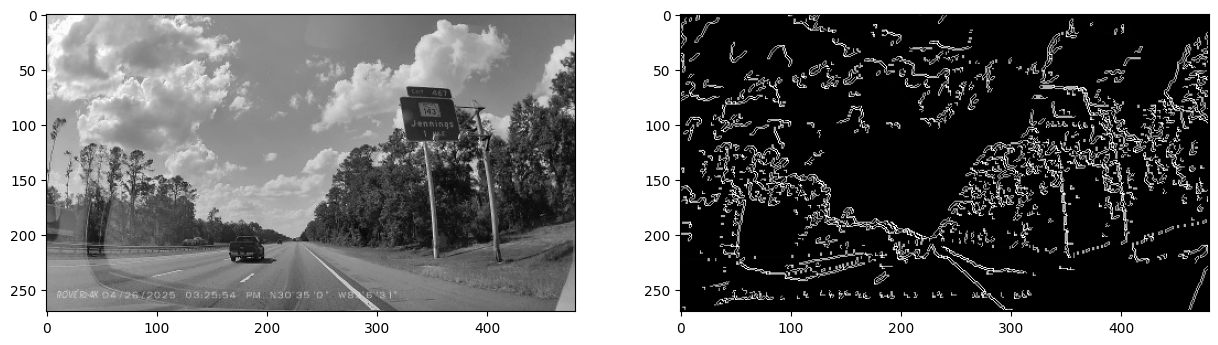

In [15]:
img_nonmax = non_max_suppression(G, theta)

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(img_nonmax, cmap="gray")

### 4. Double threshold

- Strong pixels are pixels that have an intensity so high that we are sure they contribute to the final edge.
- Weak pixels are pixels that have an intensity value that is not enough to be considered as strong ones, but yet not small enough to be considered as non-relevant for the edge detection.
- Other pixels are considered as non-relevant for the edge.

In [16]:
def threshold(img, lowThresholdRatio=0.05, highThresholdRatio=0.09):
    
    highThreshold = img.max() * highThresholdRatio;
    lowThreshold = highThreshold * lowThresholdRatio;
    
    M, N = img.shape
    res = np.zeros((M,N), dtype=np.int32)
    
    weak = np.int32(25)
    strong = np.int32(255)
    
    strong_i, strong_j = np.where(img >= highThreshold)
    zeros_i, zeros_j = np.where(img < lowThreshold)
    
    weak_i, weak_j = np.where((img <= highThreshold) & (img >= lowThreshold))
    
    res[strong_i, strong_j] = strong
    res[weak_i, weak_j] = weak
    
    return (res)

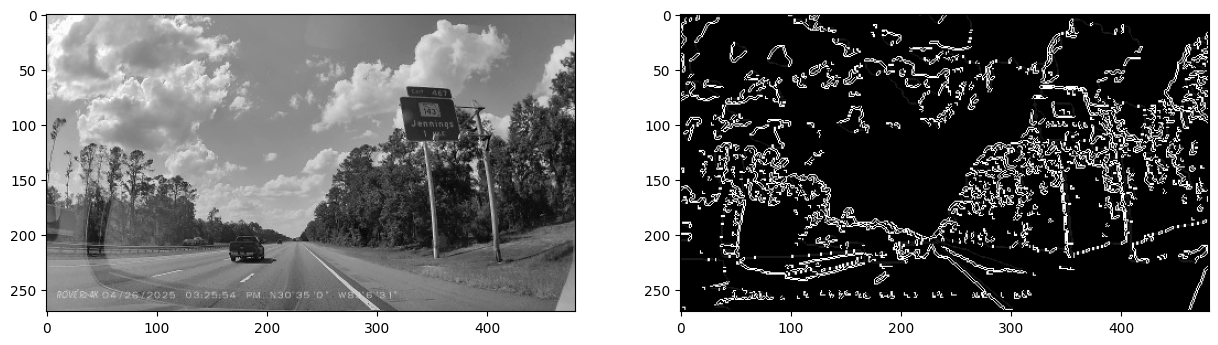

In [17]:
img_threshold = threshold(img_nonmax)

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(img_threshold, cmap="gray")

### 5. Edge Tracking by Hysteresis

The hysteresis consists of transforming weak pixels into strong ones, if and only if at least one of the pixels around the one being processed is a strong one

In [18]:
def hysteresis(img, weak = 25, strong=255):
    M, N = img.shape  
    for i in range(1, M-1):
        for j in range(1, N-1):
            if (img[i,j] == weak):
                try:
                    if ((img[i+1, j-1] == strong) or (img[i+1, j] == strong) or (img[i+1, j+1] == strong)
                        or (img[i, j-1] == strong) or (img[i, j+1] == strong)
                        or (img[i-1, j-1] == strong) or (img[i-1, j] == strong) or (img[i-1, j+1] == strong)):
                        img[i, j] = strong
                    else:
                        img[i, j] = 0
                except IndexError as e:
                    pass
    return img

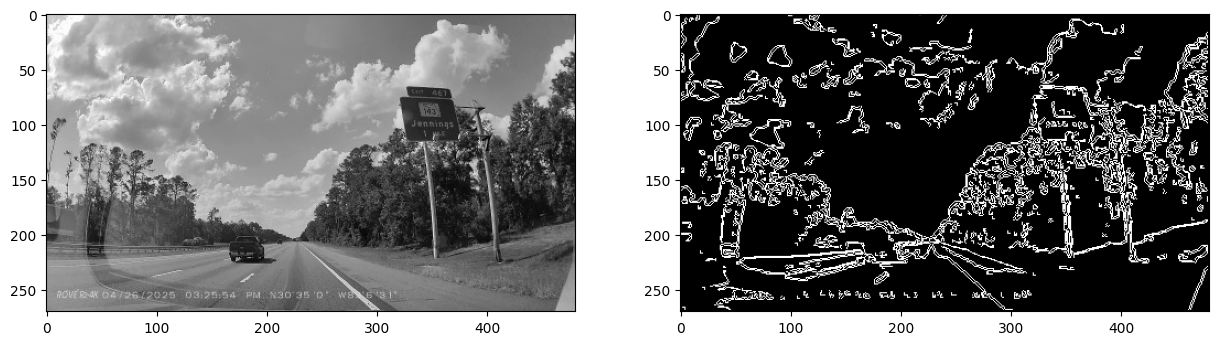

In [19]:
img_final = hysteresis(img_threshold)

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(img_final, cmap="gray")

In [20]:
# TODO: Challenge

# Experimentos de la actividad

La actividad no pide funciones nuevas sino **modificar parámetros para comprender el código** y reportar los hallazgos. Se hace en tres pasos:

1. [Sigma y tamaño del kernel](#sigma): qué cambia al modificar σ, y qué pasa con el tamaño del kernel fijo.
2. [Canny con y sin remoción de ruido](#ruido): con una verdad de bordes conocida (imagen sintética) se miden precisión, exhaustividad y F1.
3. [Imágenes con distinta cantidad de líneas y textura](#imagenes).
4. [Hallazgos](#hallazgos).

Para barrer muchos parámetros se usa `cv2.Canny` (rápido); el notebook base implementa cada etapa a mano con bucles y es demasiado lento para hacerlo decenas de veces.
Antes de los experimentos se corrigieron tres problemas del notebook base (ver «Hallazgos»).

In [21]:
import cv2, numpy as np, matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt
plt.rcParams.update({"font.size": 9})

def gauss_k(g, sigma, tam=None):
    # Gaussiano con tamaño de kernel proporcional a sigma (6σ+1, impar) salvo que se indique otro
    if sigma <= 0: return g
    tam = tam or (int(2 * np.ceil(3 * sigma) + 1))
    return cv2.GaussianBlur(g, (tam, tam), sigma)

def canny(g, sigma=1.4, bajo=50, alto=120, tam=None):
    return cv2.Canny(gauss_k(g, sigma, tam), bajo, alto)

def prf(deteccion, verdad, tol=2):
    # precisión = detectados a ≤ tol px de un borde verdadero; exhaustividad = bordes verdaderos a ≤ tol px de un detectado
    d, v = deteccion > 0, verdad > 0
    dist_v = distance_transform_edt(~v); dist_d = distance_transform_edt(~d)
    p = float((dist_v[d] <= tol).mean()) if d.any() else 0.0
    r = float((dist_d[v] <= tol).mean()) if v.any() else 0.0
    return p, r, (2 * p * r / (p + r) if p + r else 0.0)

<a id="sigma"></a>
## 1. Modificar σ y el tamaño del kernel

En el notebook base, `sigma = 10` se usa con `kernel_size = 3`. Un kernel de 3×3 solo puede representar bien un gaussiano de σ ≲ 1: si σ es mayor, los tres coeficientes por fila se vuelven casi iguales y el resultado es un simple promedio de 3×3, **por muy grande que sea σ**. Se comprueba y se compara con un kernel cuyo tamaño crece con σ (6σ+1).

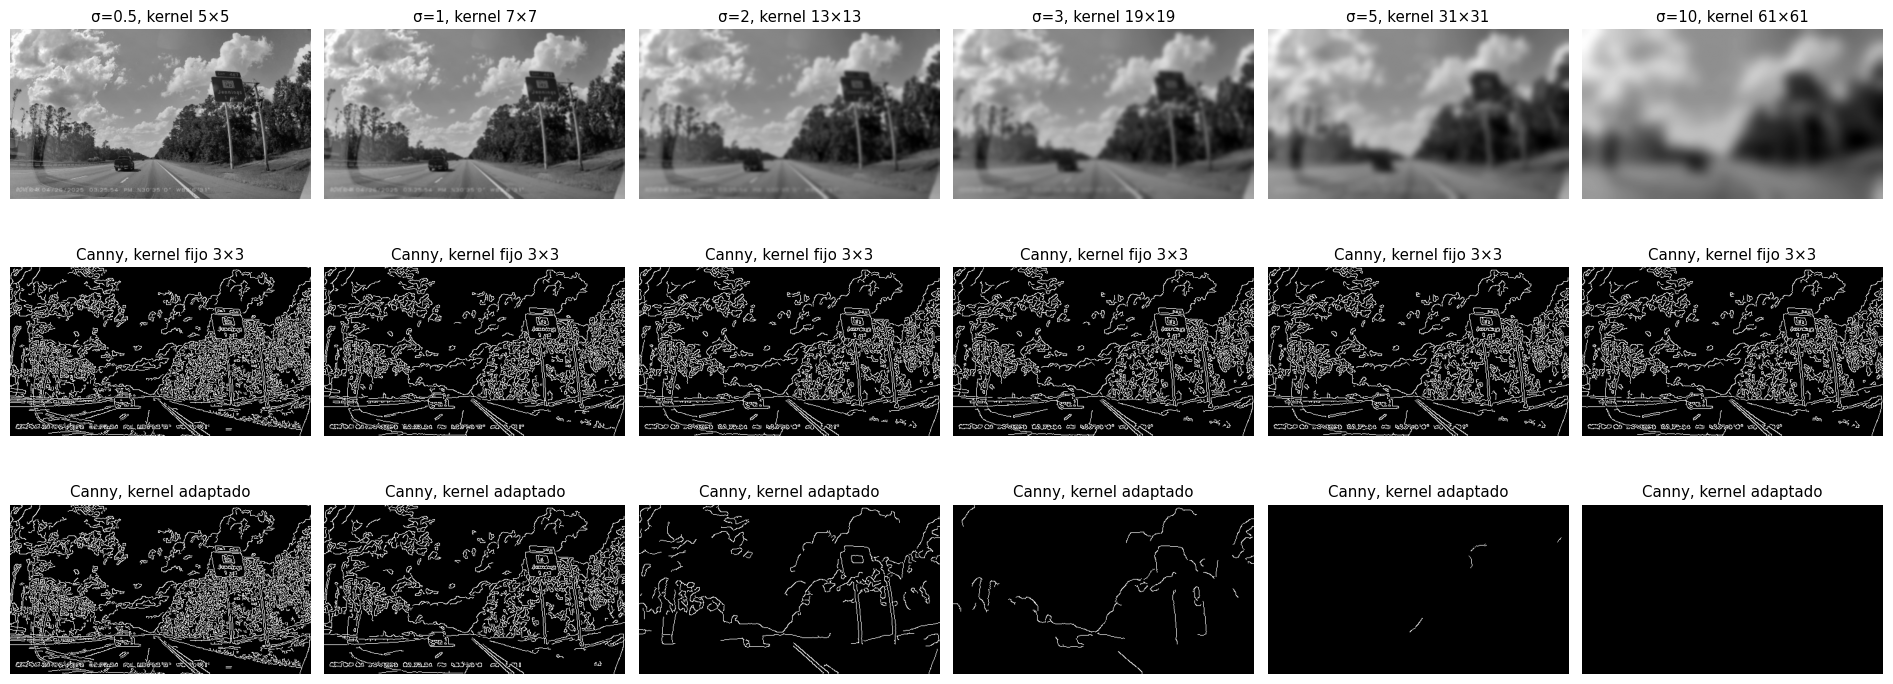

    σ  bordes % (kernel 3×3)   bordes % (kernel 6σ+1)
  0.5                  17.94                    17.94
  1.0                  14.13                    12.04
  2.0                  13.25                     4.17
  3.0                  13.07                     1.44
  5.0                  13.05                     0.07
 10.0                  13.05                     0.00


In [22]:
gris = cv2.imread("data/image.jpg", 0)
sigmas = [0.5, 1, 2, 3, 5, 10]
fig, ejes = plt.subplots(3, len(sigmas), figsize=(19, 7.6))
filas = []
for j, s in enumerate(sigmas):
    fijo = cv2.GaussianBlur(gris, (3, 3), s)                       # como en el notebook base: kernel 3x3
    adaptado = gauss_k(gris, s)                                    # kernel de tamaño 6σ+1
    e_fijo, e_ad = cv2.Canny(fijo, 40, 100), cv2.Canny(adaptado, 40, 100)
    filas.append((s, (e_fijo > 0).mean() * 100, (e_ad > 0).mean() * 100, np.abs(fijo.astype(int) - gauss_k(gris, 0.5).astype(int)).mean(), np.abs(adaptado.astype(int) - gris.astype(int)).mean()))
    ejes[0, j].imshow(adaptado, cmap="gray"); ejes[0, j].set_title(f"σ={s}, kernel {int(2*np.ceil(3*s)+1)}×{int(2*np.ceil(3*s)+1)}")
    ejes[1, j].imshow(e_fijo, cmap="gray"); ejes[1, j].set_title(f"Canny, kernel fijo 3×3")
    ejes[2, j].imshow(e_ad, cmap="gray"); ejes[2, j].set_title(f"Canny, kernel adaptado")
for a in ejes.ravel(): a.axis("off")
plt.tight_layout(); plt.show()
print(f"{'σ':>5s} {'bordes % (kernel 3×3)':>22s} {'bordes % (kernel 6σ+1)':>24s}")
for s, ef, ea, _, _ in filas: print(f"{s:5.1f} {ef:22.2f} {ea:24.2f}")

<a id="ruido"></a>
## 2. Canny con y sin remoción de ruido

Se construye una imagen sintética con bordes conocidos (rectángulo, círculo y triángulo con niveles de gris distintos, y una textura suave de fondo) y se le añade ruido gaussiano de distinta intensidad. La verdad de bordes es el contorno de cada figura. Se mide con una tolerancia de 2 píxeles.

In [23]:
def imagen_sintetica(n=320, ruido=0, semilla=0):
    rng = np.random.default_rng(semilla)
    g = np.full((n, n), 110, np.float32)
    g += cv2.GaussianBlur(rng.normal(0, 14, (n, n)).astype(np.float32), (0, 0), 6) * 2         # textura suave de fondo
    etiquetas = np.zeros((n, n), np.uint8)
    cv2.rectangle(etiquetas, (30, 40), (140, 150), 1, -1); cv2.circle(etiquetas, (225, 100), 55, 2, -1)
    cv2.fillPoly(etiquetas, [np.array([[80, 290], [160, 180], [240, 290]])], 3)
    for k, v in ((1, 200), (2, 50), (3, 170)): g[etiquetas == k] = v
    verdad = cv2.morphologyEx(etiquetas, cv2.MORPH_GRADIENT, np.ones((3, 3), np.uint8))
    g = g + rng.normal(0, ruido, g.shape)
    return np.clip(g, 0, 255).astype(np.uint8), (verdad > 0).astype(np.uint8) * 255

niveles = [0, 10, 25, 40]
sig_lista = [0, 0.7, 1.0, 1.4, 2.0, 3.0, 5.0]
tabla = {}
for nr in niveles:
    g, v = imagen_sintetica(ruido=nr)
    for s in sig_lista: tabla[(nr, s)] = prf(canny(g, s, 50, 120), v)
print("F1 de Canny (umbrales 50/120) según el ruido de la imagen (filas) y σ del suavizado previo (columnas; 0 = sin suavizar)\n")
print(f"{'ruido σn':>9s} " + " ".join(f"σ={s:<5}" for s in sig_lista))
for nr in niveles: print(f"{nr:9d} " + " ".join(f"{tabla[(nr, s)][2]:7.3f}" for s in sig_lista))
mejor = {nr: max(sig_lista, key=lambda s: tabla[(nr, s)][2]) for nr in niveles}
print("\nMejor σ por nivel de ruido:", mejor)
print("\nPrecisión / exhaustividad en la imagen con ruido σn=25:")
for s in sig_lista: print(f"  σ={s:<4} precisión {tabla[(25, s)][0]:.3f}  exhaustividad {tabla[(25, s)][1]:.3f}")

F1 de Canny (umbrales 50/120) según el ruido de la imagen (filas) y σ del suavizado previo (columnas; 0 = sin suavizar)

 ruido σn σ=0     σ=0.7   σ=1.0   σ=1.4   σ=2.0   σ=3.0   σ=5.0  
        0   1.000   1.000   1.000   1.000   0.939   0.000   0.000
       10   0.169   0.999   1.000   1.000   0.939   0.377   0.000
       25   0.131   0.112   0.291   1.000   0.999   0.274   0.000
       40   0.134   0.121   0.111   0.521   0.993   0.471   0.000

Mejor σ por nivel de ruido: {0: 0.7, 10: 1.4, 25: 1.4, 40: 2.0}

Precisión / exhaustividad en la imagen con ruido σn=25:
  σ=0    precisión 0.070  exhaustividad 1.000
  σ=0.7  precisión 0.060  exhaustividad 1.000
  σ=1.0  precisión 0.170  exhaustividad 1.000
  σ=1.4  precisión 1.000  exhaustividad 1.000
  σ=2.0  precisión 1.000  exhaustividad 0.998
  σ=3.0  precisión 1.000  exhaustividad 0.159
  σ=5.0  precisión 0.000  exhaustividad 0.000


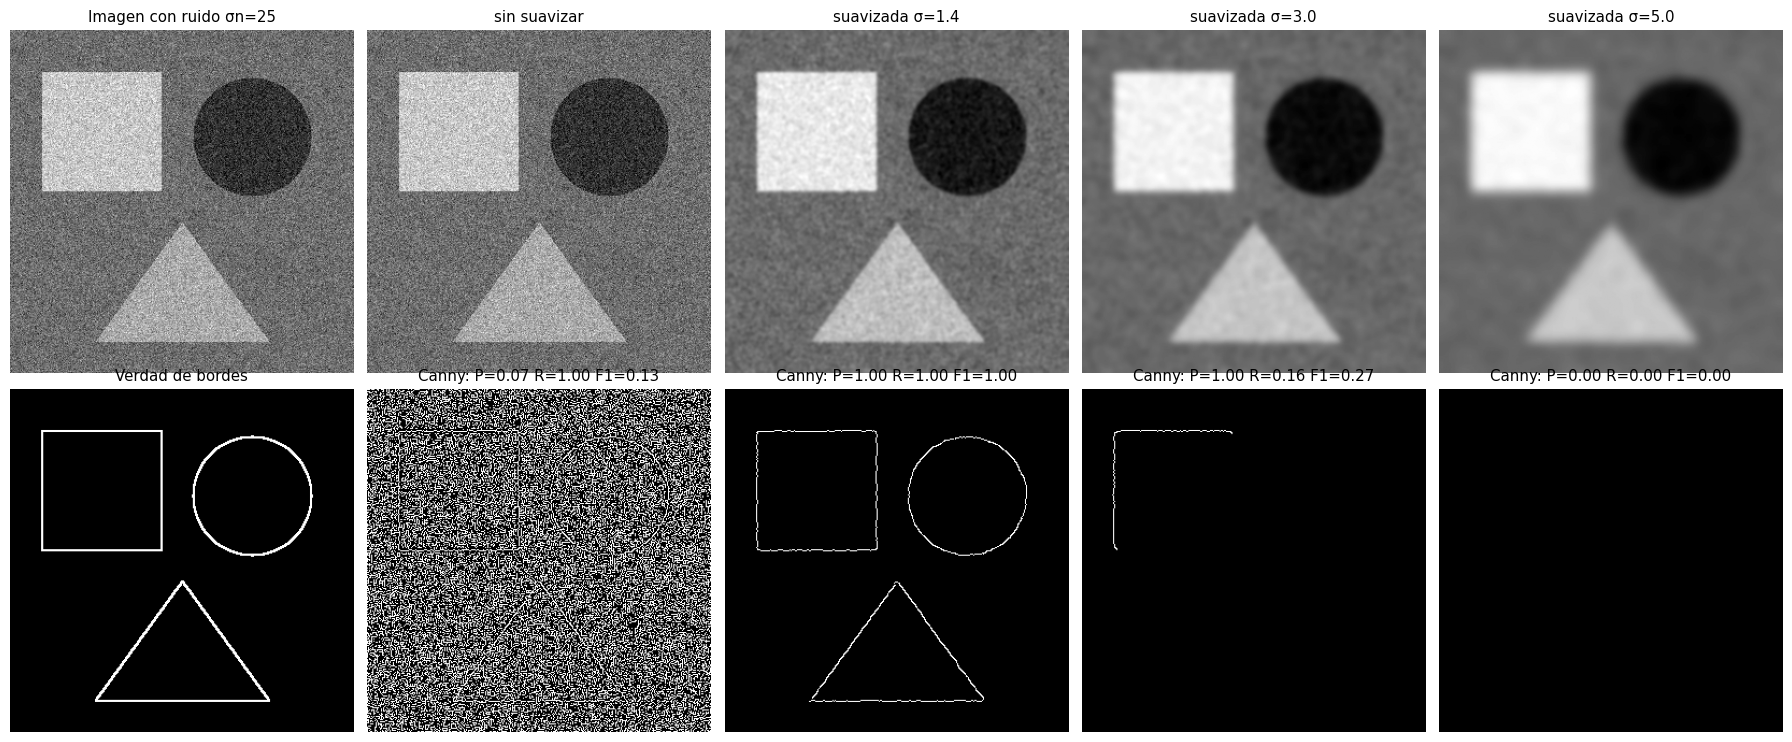

In [24]:
g, v = imagen_sintetica(ruido=25)
fig, ejes = plt.subplots(2, 5, figsize=(18, 7.4))
ejes[0, 0].imshow(g, cmap="gray"); ejes[0, 0].set_title("Imagen con ruido σn=25"); ejes[1, 0].imshow(v, cmap="gray"); ejes[1, 0].set_title("Verdad de bordes")
for j, s in enumerate((0, 1.4, 3.0, 5.0), start=1):
    e = canny(g, s, 50, 120); p, r, f = prf(e, v)
    ejes[0, j].imshow(gauss_k(g, s), cmap="gray"); ejes[0, j].set_title("sin suavizar" if s == 0 else f"suavizada σ={s}")
    ejes[1, j].imshow(e, cmap="gray"); ejes[1, j].set_title(f"Canny: P={p:.2f} R={r:.2f} F1={f:.2f}")
for a in ejes.ravel(): a.axis("off")
plt.tight_layout(); plt.show()

<a id="imagenes"></a>
## 3. Imágenes con distinta cantidad de líneas y textura

Con σ=1.4 y umbrales fijos, se aplica Canny a cuatro imágenes de naturaleza distinta y se mide la **densidad de bordes** (porcentaje de píxeles marcados) y el número de componentes conexos.

imagen                                  σ=1.4: bordes %  componentes  σ=3: bordes %
Autopista (pocas líneas)                           4.85          211           0.57
Escena urbana (muchas líneas)                      6.98          327           0.63
Células fluorescentes (textura fina)               3.40          269           1.23
Microscopía (fondo liso)                           4.06          101           0.06


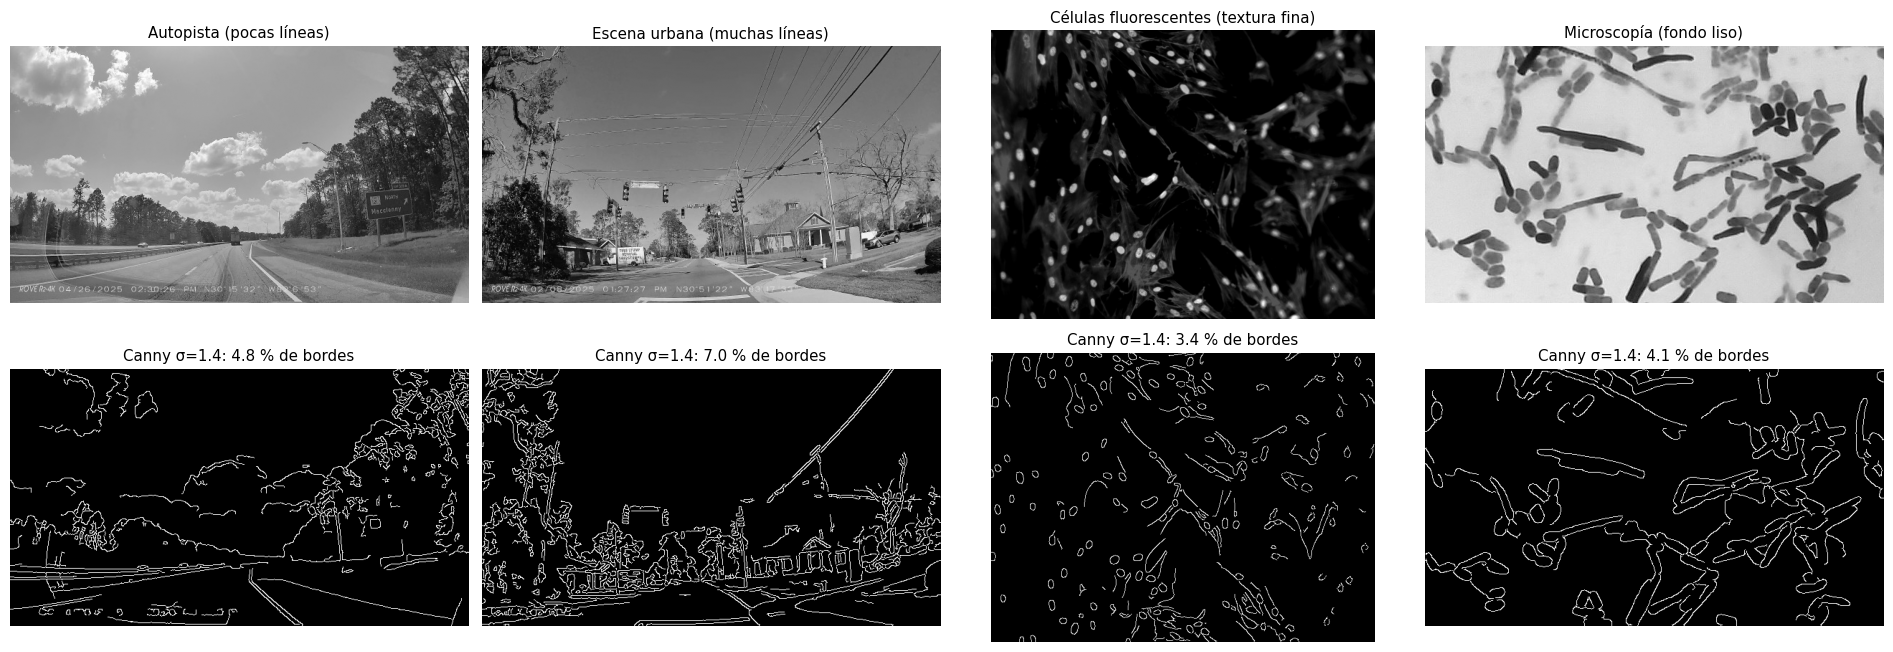

In [25]:
imagenes = {"Autopista (pocas líneas)": "data/autopista.jpg", "Escena urbana (muchas líneas)": "data/escena_urbana.jpg",
            "Células fluorescentes (textura fina)": "data/textura_celulas.jpg", "Microscopía (fondo liso)": "data/microscopia.jpg"}
fig, ejes = plt.subplots(2, 4, figsize=(19, 6.6))
print(f"{'imagen':38s} {'σ=1.4: bordes %':>16s} {'componentes':>12s} {'σ=3: bordes %':>14s}")
for j, (nombre, ruta) in enumerate(imagenes.items()):
    g = cv2.imread(ruta, 0); e = canny(g, 1.4, 50, 120); e3 = canny(g, 3.0, 50, 120)
    n_comp = cv2.connectedComponents(e, connectivity=8)[0] - 1
    print(f"{nombre:38s} {(e > 0).mean() * 100:16.2f} {n_comp:12d} {(e3 > 0).mean() * 100:14.2f}")
    ejes[0, j].imshow(g, cmap="gray"); ejes[0, j].set_title(nombre); ejes[1, j].imshow(e, cmap="gray"); ejes[1, j].set_title(f"Canny σ=1.4: {(e > 0).mean() * 100:.1f} % de bordes")
for a in ejes.ravel(): a.axis("off")
plt.tight_layout(); plt.show()

<a id="hallazgos"></a>
## 4. Hallazgos


**1. Efecto de σ y del tamaño del kernel.**
- Al aumentar σ el suavizado previo elimina detalle fino y, con él, líneas. Con un kernel adaptado (6σ+1) el porcentaje de píxeles de borde baja de 17.9 % (σ=0.5) a 12.0 % (σ=1), 4.2 % (σ=2), 1.4 % (σ=3), 0.07 % (σ=5) y 0 % (σ=10): con σ=10 la imagen queda tan borrosa que ningún gradiente supera los umbrales.
- **Con el kernel fijo de 3×3 del notebook base, σ deja de tener efecto a partir de σ≈2**: el porcentaje de bordes se estanca en 13.1 % (13.25 %, 13.07 %, 13.05 %, 13.05 % para σ = 2, 3, 5 y 10). Un kernel de 3×3 solo representa un gaussiano con σ ≲ 1; para σ mayor se convierte en un promedio uniforme. Por eso los valores «1, 3, 5, 10, 20» que sugiere el notebook no producen resultados distintos si no se aumenta también `kernel_size`.
- Regla práctica: el tamaño del kernel debe ser al menos 6σ+1.

**2. Con y sin remoción de ruido.** En una imagen sintética con bordes conocidos (tolerancia de 2 px) se midió el F1 de Canny con umbrales fijos:
- **Sin suavizar, el ruido arruina el resultado**: con ruido de σn=10 el F1 es 0.17 y con σn=25 es 0.13, porque la exhaustividad es 1.0 (se detectan todos los bordes reales) pero la precisión es de solo 0.07 con σn=25 (más del 90 % de lo detectado es ruido).
- Con el suavizado adecuado el F1 llega a 1.000 con σn=10 (σ=1.0), 1.000 con σn=25 (σ=1.4) y 0.993 con σn=40 (σ=2.0). **El σ óptimo crece con el ruido** (0.7–1.0 → 1.4 → 2.0).
- Un suavizado excesivo también falla: con σn=25 y σ=3 la exhaustividad cae a 0.16 y con σ=5 se pierde todo. Ojo: con umbrales fijos, un σ grande reduce la magnitud del gradiente, así que en la imagen limpia con σ=3 o σ=5 el F1 es 0.000 aunque el borde sigue ahí; al suavizar más hay que bajar también los umbrales.
- Conclusión: **la remoción de ruido no es opcional**; el primer paso de Canny es necesario, y su intensidad debe ajustarse al ruido y a los umbrales.

**3. Imágenes con distinta cantidad de líneas y textura** (σ=1.4, umbrales 50/120):
- La escena urbana, con muchas líneas (ventanas, cables, señales), es la que tiene más bordes (7.0 % de píxeles, 327 componentes); la autopista, con pocas líneas, 4.9 % (211 componentes).
- La imagen de células, de textura fina, tiene una densidad de bordes menor (3.4 %) pero **es la que más bordes conserva al subir σ a 3 (1.2 %)**, porque el contorno de las células es un borde amplio; en cambio, la microscopía de fondo liso cae a 0.06 %, pues sus contornos son de bajo contraste.
- Un solo par de umbrales no sirve para todas las imágenes: las de bajo contraste requieren umbrales menores, y las texturadas, mayores para no llenarse de bordes espurios.

**4. Correcciones al notebook base** (afectan también al Colab actual):
- `scipy.ndimage.filters` ya no existe (se usa `scipy.ndimage`).
- La función `threshold` marca los píxeles débiles con el valor 25, pero `hysteresis` los buscaba con 75 por defecto, de modo que **la histéresis no promovía ningún píxel débil**; se cambió el valor por defecto a 25.
- `data/img.npy` lo crea el notebook de la práctica 2; aquí se genera junto con `data/image.jpg`.

**Limitaciones.** La imagen sintética es sencilla (tres figuras de bordes limpios), por lo que el F1 alcanza 1.0; con imágenes reales no hay una verdad de bordes objetiva y se recurre a la inspección visual y a la densidad de bordes. Los barridos usan `cv2.Canny`, cuya implementación coincide en concepto con la del notebook base pero no es idéntica pixel a pixel.


## Referencias

- Canny, J. (1986). A computational approach to edge detection. *IEEE Transactions on Pattern Analysis and Machine Intelligence, PAMI-8*(6), 679–698. https://doi.org/10.1109/TPAMI.1986.4767851
- Gonzalez, R. C., & Woods, R. E. (2018). *Digital image processing* (4.ª ed.). Pearson. (Cap. 10.)
- Sobel, I., & Feldman, G. (1968). *A 3x3 isotropic gradient operator for image processing* [Presentación]. Stanford Artificial Intelligence Project (SAIL).
- Bradski, G. (2000). The OpenCV library. *Dr. Dobb's Journal of Software Tools, 25*(11), 120–123.
- Imágenes: ver `LICENCIAS.md` (Wikimedia Commons: Rivera, CC BY 4.0 y CC0; Arnatbio, CC BY-SA 4.0; Chaurasiya, CC0). La imagen sintética se genera por código.